In [46]:
import pandas as pd
import math
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pyvis.network import Network

In [ ]:
df = pd.read_csv("Email-Enron-undirected.csv")

G = nx.from_pandas_edgelist(df, source=df.columns[0], target=df.columns[1])

In [18]:
nx.is_connected(G)

False

In [19]:
lcc = list(nx.connected_components(G))[0]

# Subset of x% nodes with highest degree

In [20]:
A=G.copy()
x = 0.05
deg_list = sorted(A.degree(), key=lambda x: x[1], reverse=True)
k = math.ceil(x * len(deg_list))
remove = [n for n, d in deg_list[k:]]

A.remove_nodes_from(remove)

In [21]:
node, degree = max(A.degree(), key=lambda x: x[1])
print("Max degree:", degree)

Max degree: 550


# K-core Decomposition

Using network x, we obtain the k-core for every k

In [22]:
B = G.copy()
cores = []
i = 2

while len(B.nodes()) != 0:
    cores.append(B)
    B = nx.k_core(B, i)
    
    i += 1

print(len(cores[-1]))

275


In [23]:
[(i, len(c)) for (i, c) in enumerate(cores)]

[(0, 36692),
 (1, 25286),
 (2, 21309),
 (3, 15386),
 (4, 11648),
 (5, 9290),
 (6, 7061),
 (7, 5905),
 (8, 5088),
 (9, 4513),
 (10, 4126),
 (11, 3802),
 (12, 3530),
 (13, 3300),
 (14, 3062),
 (15, 2873),
 (16, 2707),
 (17, 2561),
 (18, 2416),
 (19, 2276),
 (20, 2162),
 (21, 2055),
 (22, 1944),
 (23, 1836),
 (24, 1731),
 (25, 1639),
 (26, 1553),
 (27, 1469),
 (28, 1367),
 (29, 1276),
 (30, 1170),
 (31, 1079),
 (32, 987),
 (33, 935),
 (34, 781),
 (35, 710),
 (36, 633),
 (37, 592),
 (38, 516),
 (39, 456),
 (40, 370),
 (41, 327),
 (42, 275)]

We select which one we want to study:

In [24]:
C = cores[max(range(len(cores)), key=lambda k: k * len(cores[k]))]
print(C)

Graph with 11648 nodes and 138578 edges


In [25]:
print(nx.is_connected(C))
print(len(list(nx.connected_components(C))))

False
15


We then extract the largest core component

In [26]:
largest_nodes = max(nx.connected_components(C), key=len)
D = C.subgraph(largest_nodes).copy()
print(D)
print(nx.is_connected(D))
print(nx.is_directed(G))

Graph with 11538 nodes and 138245 edges
True
False


# Network Analysis

We first get the number of nodes, edges and calculate the density

In [ ]:
n_nodes = D.number_of_nodes()
print(n_nodes)
n_edges = D.number_of_edges()
print(n_edges)
density = nx.density(D)
print(density)

11538
138245
0.002077093282800972


Now we get the degree of each node, plot it and get the average degree

In [ ]:
degrees = [D.degree(n) for n in D.nodes]
avg_degree = sum(degrees)/len(D)
print(avg_degree)

23.963425203674813


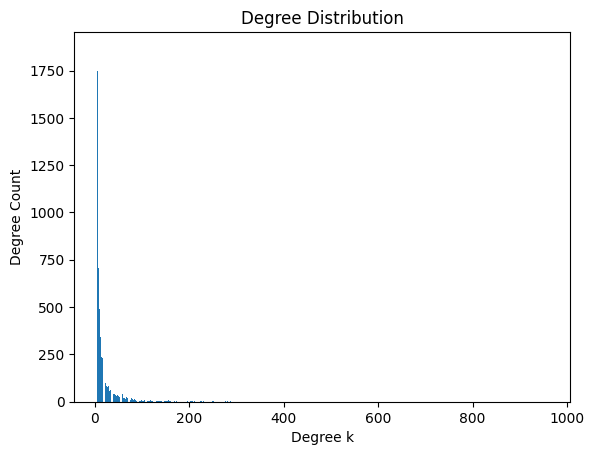

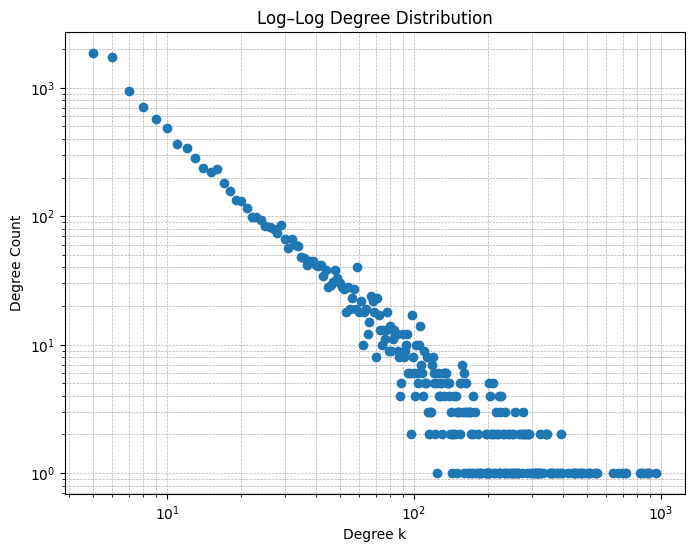

In [ ]:
degree_counts = Counter(degrees)
min_degree, max_degree = min(degree_counts.keys()), max(degree_counts.keys())

#Plot the distribution
plot_x = list(range(min_degree, max_degree + 1))
plot_y = [degree_counts.get(x, 0) for x in plot_x]
plt.xlabel("Degree k")
plt.ylabel("Degree Count")
plt.title("Degree Distribution")
plt.bar(plot_x, plot_y)
plt.show()

# Plot on log–log scale
plt.figure(figsize=(8,6))
plt.loglog(plot_x, plot_y, marker='o', linestyle='none')
plt.xlabel("Degree k")
plt.ylabel("Degree Count")
plt.title("Log–Log Degree Distribution")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

Now we calculate the centralities and plot them

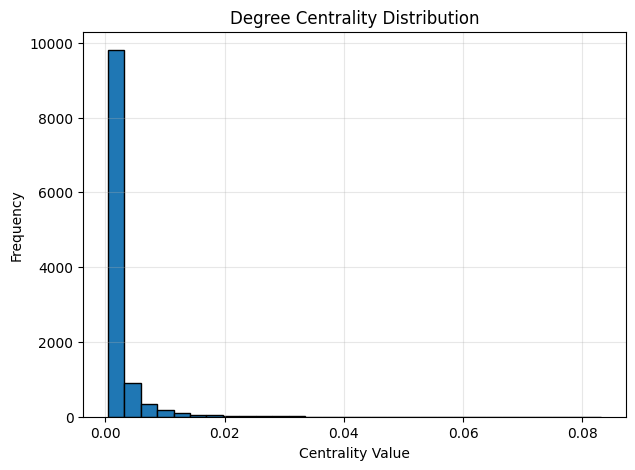

In [ ]:
degree_centrality = nx.degree_centrality(D)
#print(degree_centrality)

values = list(degree_centrality.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Degree Centrality Distribution")
plt.xlabel("Centrality Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

In [52]:
betweenness_centrality = nx.betweenness_centrality(D)
#print(betweenness_centrality)

values = list(betweenness_centrality.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Betweenness Centrality Distribution")
plt.xlabel("Centrality Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

KeyboardInterrupt: 

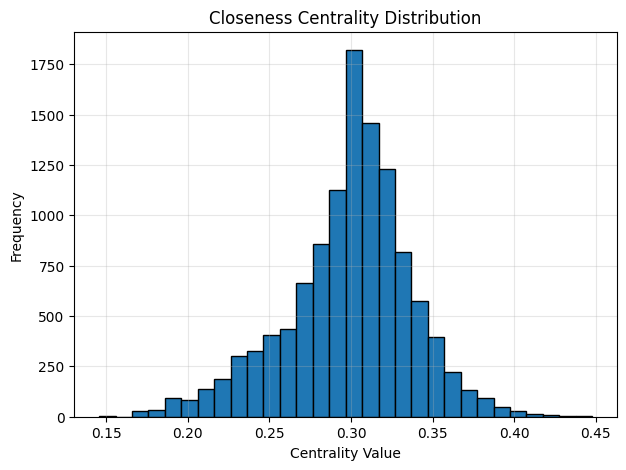

In [ ]:
closeness_centrality = nx.closeness_centrality(D)
#print(closeness_centrality)

values = list(closeness_centrality.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Closeness Centrality Distribution")
plt.xlabel("Centrality Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

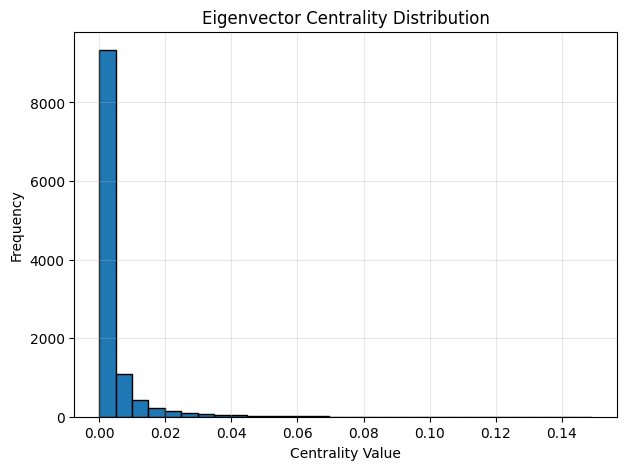

In [ ]:
eigenvector_centrality = nx.eigenvector_centrality(D)
#print(eigenvector_centrality)

values = list(eigenvector_centrality.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Eigenvector Centrality Distribution")
plt.xlabel("Centrality Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

Now we calculate the paths

In [ ]:
avg_shortest_path = nx.average_shortest_path_length(D)
print(avg_shortest_path)
diameter = nx.diameter(D)
print(diameter)

3.410414791674733
9


Now we calculate the clustering and plot it

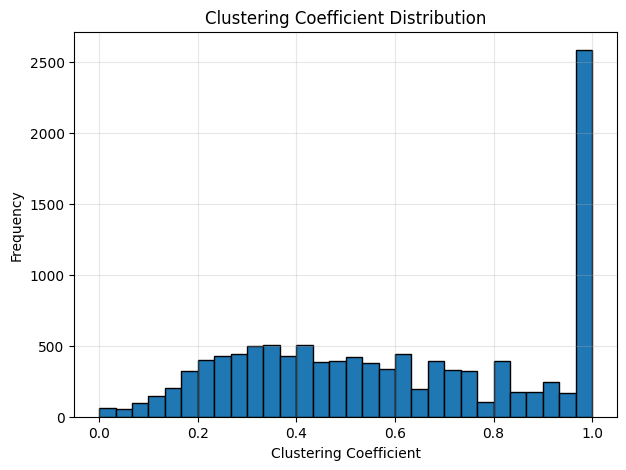

0.6001678066423783


In [ ]:
clustering = nx.clustering(D)
#print(clustering)

values = list(clustering.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Clustering Coefficient Distribution")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

avg_clustering = nx.average_clustering(D)
print(avg_clustering)

Now we proceed toward Community Detection

In [53]:
best_mod = -1
best_comm = None

for seed in range(10):
    comm = louvain_communities(D, seed=seed)
    mod = modularity(D, comm)
    if mod > best_mod:
        best_mod = mod
        best_comm = comm

communities = best_comm
print("Best modularity:", best_mod)
print("Number of communities:", len(communities))

Best modularity: 0.5519219309711104
Number of communities: 79


Now we represent the communities of the network

In [59]:
# Map each node to its community ID
node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

# ----------------------------------------
# 1. Generate distinct colors for communities
# ----------------------------------------
# Use HSV-based distinct colors for many communities
def get_distinct_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        colors.append(mcolors.to_hex(mcolors.hsv_to_rgb((hue, 0.7, 0.9))))
    return colors

colors = get_distinct_colors(num_communities)
community_colors = {i: colors[i] for i in range(num_communities)}

# ----------------------------------------
# 2. Build meta-graph (one node per community)
# ----------------------------------------
metaG = nx.Graph()
# Add meta-nodes
for i, comm in enumerate(communities):
    metaG.add_node(i, size=len(comm), color=community_colors[i], title=f"Community {i}, size {len(comm)}")

# Add weighted edges between communities
for i, ci in enumerate(communities):
    for j, cj in enumerate(communities):
        if i < j:
            # Count edges connecting community i to community j
            weight = sum(1 for u in ci for v in cj if D.has_edge(u, v))
            if weight > 0:
                metaG.add_edge(i, j, weight=weight)

# ----------------------------------------
# 3. Create Pyvis network
# ----------------------------------------
net = Network(height="700px", width="100%", notebook=True, bgcolor="#222222", font_color="white", cdn_resources='in_line')

# Add meta-nodes
for n, data in metaG.nodes(data=True):
    net.add_node(n, 
                 label=str(n),
                 title=data['title'],
                 color=data['color'],
                 value=data['size'])  # size proportional to number of nodes

# Add weighted edges
for u, v, data in metaG.edges(data=True):
    net.add_edge(u, v, value=data['weight'], title=f"Weight: {data['weight']}")

# Layout physics
net.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=200, spring_strength=0.01, damping=0.4)

from IPython.display import display, HTML
# Show interactive network
html = net.generate_html()
with open("example.html", mode='w', encoding='utf-8') as fp:
        fp.write(html)
display(HTML(html))